In [23]:
import pandas as pd


In [24]:
df = pd.read_excel("output(d).xlsx")

In [26]:
df.columns

Index(['CNR', 'case_details', 'outcome', 'reason_court', 'pred_base',
       'pred_ft', 'reason_baseline', 'reason_ft',
       'evaluation.evaluator_1.ft_evaluation.fa',
       'evaluation.evaluator_1.ft_evaluation.c1',
       'evaluation.evaluator_1.ft_evaluation.c2',
       'evaluation.evaluator_1.baseline_evaluation.fa',
       'evaluation.evaluator_1.baseline_evaluation.c1',
       'evaluation.evaluator_1.baseline_evaluation.c2',
       'evaluation.evaluator_1.flag', 'evaluation.evaluator_1.comments',
       'evaluation.evaluator_2.ft_evaluation.fa',
       'evaluation.evaluator_2.ft_evaluation.c1',
       'evaluation.evaluator_2.ft_evaluation.c2',
       'evaluation.evaluator_2.baseline_evaluation.fa',
       'evaluation.evaluator_2.baseline_evaluation.c1',
       'evaluation.evaluator_2.baseline_evaluation.c2',
       'evaluation.evaluator_2.flag', 'evaluation.evaluator_2.comments'],
      dtype='object')

In [27]:
useful_columns = [col for col in df.columns if col.startswith("evaluation") and not col.endswith(("flag", "comments"))]

In [28]:
useful_columns

['evaluation.evaluator_1.ft_evaluation.fa',
 'evaluation.evaluator_1.ft_evaluation.c1',
 'evaluation.evaluator_1.ft_evaluation.c2',
 'evaluation.evaluator_1.baseline_evaluation.fa',
 'evaluation.evaluator_1.baseline_evaluation.c1',
 'evaluation.evaluator_1.baseline_evaluation.c2',
 'evaluation.evaluator_2.ft_evaluation.fa',
 'evaluation.evaluator_2.ft_evaluation.c1',
 'evaluation.evaluator_2.ft_evaluation.c2',
 'evaluation.evaluator_2.baseline_evaluation.fa',
 'evaluation.evaluator_2.baseline_evaluation.c1',
 'evaluation.evaluator_2.baseline_evaluation.c2']

In [29]:
import numpy as np
import krippendorff

criteria = ["fa", "c1", "c2"]
models = ["ft_evaluation", "baseline_evaluation"]

results = {}

for model in models:
    for crit in criteria:

        col1 = f"evaluation.evaluator_1.{model}.{crit}"
        col2 = f"evaluation.evaluator_2.{model}.{crit}"

        # build annotator x items matrix
        data = np.array([
            df[col1].values,
            df[col2].values
        ])

        alpha = krippendorff.alpha(
            reliability_data=data,
            level_of_measurement="ratio"
        )

        results[f"{model}_{crit}"] = alpha


# print results
for k, v in results.items():
    print(f"{k}: {v:.3f}")

ft_evaluation_fa: 0.486
ft_evaluation_c1: 0.593
ft_evaluation_c2: 0.488
baseline_evaluation_fa: 0.815
baseline_evaluation_c1: 0.921
baseline_evaluation_c2: 0.948


mean: 0.600
variance: 1.388
Series([], Name: CNR, dtype: object)


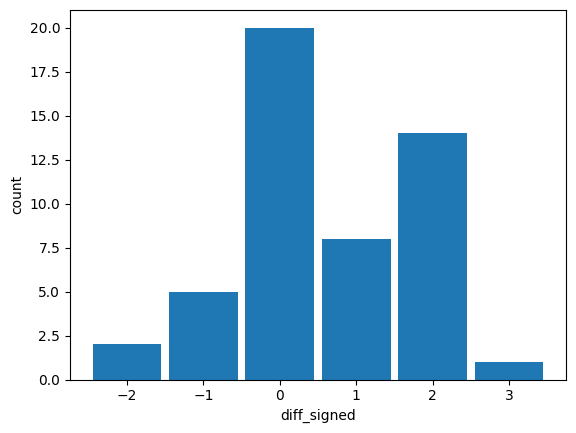

In [30]:
cols = [
    'evaluation.evaluator_1.ft_evaluation.fa',
    'evaluation.evaluator_2.ft_evaluation.fa'
]

df[cols].assign(
    diff_signed=(df[cols[0]] - df[cols[1]]).map('{:+d}'.format)
)

diff_signed = df[cols[0]] - df[cols[1]]

ax = diff_signed.plot.hist(
    bins=np.arange(diff_signed.min() - 0.5, diff_signed.max() + 1.5, 1),
    rwidth=0.9
)
ax.set_xlabel("diff_signed")
ax.set_ylabel("count")
print(f"mean: {diff_signed.mean():.3f}")
print(f"variance: {diff_signed.var():.3f}")
print(df.loc[diff_signed.abs() > 3, "CNR"])

In [31]:
from scipy.stats import spearmanr

spearman_results = {}

for model in models:
    for crit in criteria:

        col1 = f"evaluation.evaluator_1.{model}.{crit}"
        col2 = f"evaluation.evaluator_2.{model}.{crit}"

        rho, p = spearmanr(df[col1], df[col2])

        spearman_results[f"{model}_{crit}"] = rho

for k, v in spearman_results.items():
    print(f"{k}: {v:.3f}")

ft_evaluation_fa: 0.471
ft_evaluation_c1: 0.553
ft_evaluation_c2: 0.382
baseline_evaluation_fa: 0.699
baseline_evaluation_c1: 0.842
baseline_evaluation_c2: 0.711


In [32]:
import numpy as np
import pandas as pd
import krippendorff
from scipy.stats import spearmanr, kendalltau
import pingouin as pg

criteria = ["fa", "c1", "c2"]
models = ["ft_evaluation", "baseline_evaluation"]

rows = []

for model in models:
    for crit in criteria:

        col1 = f"evaluation.evaluator_1.{model}.{crit}"
        col2 = f"evaluation.evaluator_2.{model}.{crit}"

        x = df[col1].values
        y = df[col2].values

        # --- Krippendorff Alpha ---
        data = np.array([x, y])
        alpha = krippendorff.alpha(
            reliability_data=data,
            level_of_measurement="ratio"
        )

        # --- Spearman ---
        spearman, _ = spearmanr(x, y)

        # --- Kendall Tau ---
        tau, _ = kendalltau(x, y)

        # --- MAD ---
        mad = np.mean(np.abs(x - y))

        # --- ICC ---
        temp = pd.DataFrame({
            "item": np.repeat(np.arange(len(x)), 2),
            "annotator": ["A1", "A2"] * len(x),
            "score": np.concatenate([x, y])
        })

        icc = pg.intraclass_corr(
            data=temp,
            targets="item",
            raters="annotator",
            ratings="score"
        )

        icc_value = icc.loc[icc["Type"] == "ICC2", "ICC"].values[0]

        rows.append({
            "model": model,
            "criterion": crit,
            "kripp_alpha": alpha,
            "spearman": spearman,
            "kendall_tau": tau,
            "ICC2": icc_value,
            "MAD": mad
        })

results_df = pd.DataFrame(rows)

print(results_df.round(3))

                 model criterion  kripp_alpha  spearman  kendall_tau   ICC2  \
0        ft_evaluation        fa        0.486     0.471        0.405 -0.166   
1        ft_evaluation        c1        0.593     0.553        0.469 -0.039   
2        ft_evaluation        c2        0.488     0.382        0.338  0.127   
3  baseline_evaluation        fa        0.815     0.699        0.610 -0.123   
4  baseline_evaluation        c1        0.921     0.842        0.747 -0.208   
5  baseline_evaluation        c2        0.948     0.711        0.600 -0.093   

    MAD  
0  0.96  
1  1.04  
2  0.90  
3  0.90  
4  0.78  
5  1.04  
